# Level 2 — Task 3: Clustering (K-Means)

In [1]:
# Mount + Import + Load
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('/content/drive/MyDrive/Codveda Technologies Data Science task List/Data Set For Task/1) iris.csv')
print("Shape:", df.shape)
print(df.head())

Mounted at /content/drive
Shape: (150, 5)
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [2]:
# Preprocessing
# Species drop — unsupervised, no labels needed
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features:", X.columns.tolist())
print("Scaled shape:", X_scaled.shape)

Features: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
Scaled shape: (150, 4)


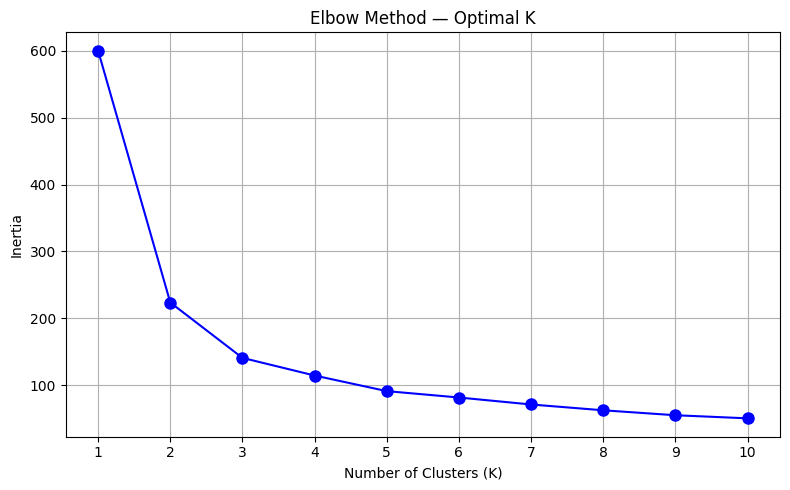

In [3]:
# Elbow Method
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertia, 'bo-', markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Optimal K')
plt.xticks(list(k_range))
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/elbow_method.png')
plt.show()

K=2 -> Silhouette Score: 0.5802
K=3 -> Silhouette Score: 0.4590
K=4 -> Silhouette Score: 0.3853
K=5 -> Silhouette Score: 0.3473
K=6 -> Silhouette Score: 0.3407
K=7 -> Silhouette Score: 0.3288
K=8 -> Silhouette Score: 0.3404
K=9 -> Silhouette Score: 0.3427
K=10 -> Silhouette Score: 0.3404


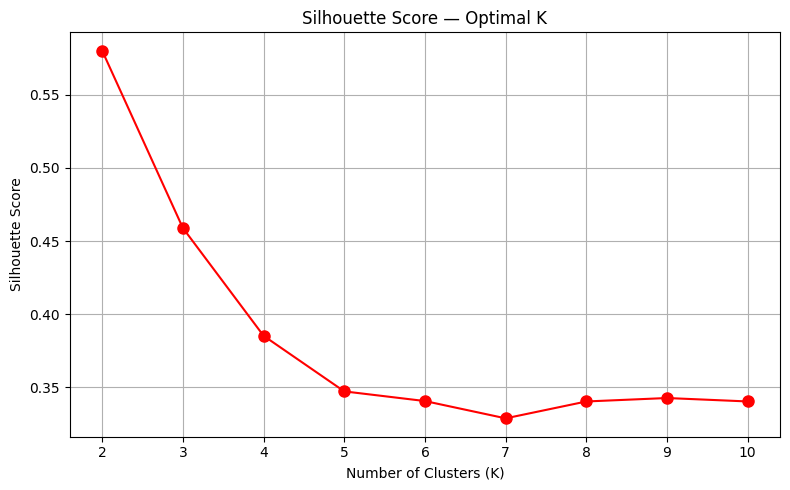

In [4]:
# Silhouette Score
sil_scores = []
k_range2 = range(2, 11)

for k in k_range2:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"K={k} -> Silhouette Score: {score:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(list(k_range2), sil_scores, 'ro-', markersize=8)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score — Optimal K')
plt.xticks(list(k_range2))
plt.grid(True)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/silhouette_score.png')
plt.show()

In [5]:
# K-Means with K=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster Distribution:")
print(df['cluster'].value_counts())
print("\nSample data with cluster labels:")
print(df.head(10))

Cluster Distribution:
cluster
0    53
1    50
2    47
Name: count, dtype: int64

Sample data with cluster labels:
   sepal_length  sepal_width  petal_length  petal_width species  cluster
0           5.1          3.5           1.4          0.2  setosa        1
1           4.9          3.0           1.4          0.2  setosa        1
2           4.7          3.2           1.3          0.2  setosa        1
3           4.6          3.1           1.5          0.2  setosa        1
4           5.0          3.6           1.4          0.2  setosa        1
5           5.4          3.9           1.7          0.4  setosa        1
6           4.6          3.4           1.4          0.3  setosa        1
7           5.0          3.4           1.5          0.2  setosa        1
8           4.4          2.9           1.4          0.2  setosa        1
9           4.9          3.1           1.5          0.1  setosa        1


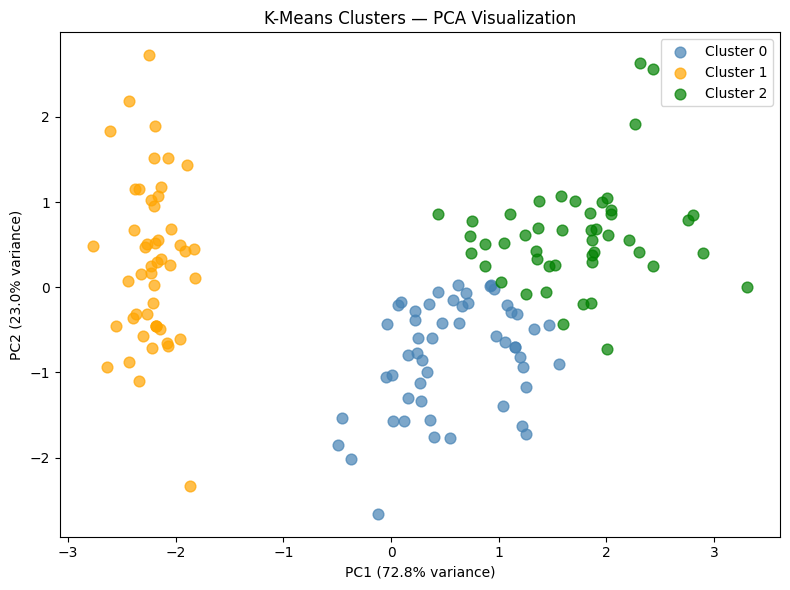

In [6]:
# PCA Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
colors = ['steelblue', 'orange', 'green']

for cluster in range(3):
    mask = df['cluster'].values == cluster
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[cluster],
                label=f'Cluster {cluster}',
                s=60, alpha=0.7)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('K-Means Clusters — PCA Visualization')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/kmeans_pca.png')
plt.show()

In [7]:
# Cluster Summary Report
centers = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers, columns=X.columns)

print("="*55)
print("        CLUSTERING SUMMARY REPORT")
print("="*55)
print(f"\nOptimal K : 3 (Elbow + Silhouette method)")
print(f"\nCluster Distribution:")
print(df['cluster'].value_counts())
print(f"\nCluster Centers (original scale):")
print(centers_df.round(2))
print(f"\nPCA Explained Variance:")
print(f"  PC1   : {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2   : {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"  Total : {sum(pca.explained_variance_ratio_)*100:.1f}%")
print("\nInsight 1: K=3 is optimal — matches 3 iris species")
print("Insight 2: Clusters are well separated in PCA space")
print("Insight 3: Petal features drive cluster separation most")
print("="*55)

        CLUSTERING SUMMARY REPORT

Optimal K : 3 (Elbow + Silhouette method)

Cluster Distribution:
cluster
0    53
1    50
2    47
Name: count, dtype: int64

Cluster Centers (original scale):
   sepal_length  sepal_width  petal_length  petal_width
0          5.80         2.67          4.37         1.41
1          5.01         3.42          1.46         0.24
2          6.78         3.10          5.51         1.97

PCA Explained Variance:
  PC1   : 72.8%
  PC2   : 23.0%
  Total : 95.8%

Insight 1: K=3 is optimal — matches 3 iris species
Insight 2: Clusters are well separated in PCA space
Insight 3: Petal features drive cluster separation most
